In [2]:
import pandas as pd
import requests

In [3]:
districts = {
    "Colombo": {
        "lat": 6.9271,
        "lon": 79.8612
    },
    "Kandy": {
        "lat": 7.2906,
        "lon": 80.6337
    },
    "Jaffna": {
        "lat": 9.6615,
        "lon": 80.0255
    },
    "Anuradhapura": {
        "lat": 8.3114,
        "lon": 80.4037
    },
    "Batticaloa": {
        "lat": 7.7102,
        "lon": 81.6924
    }
}

print("Districts Loaded:", len(districts))

districts

Districts Loaded: 5


{'Colombo': {'lat': 6.9271, 'lon': 79.8612},
 'Kandy': {'lat': 7.2906, 'lon': 80.6337},
 'Jaffna': {'lat': 9.6615, 'lon': 80.0255},
 'Anuradhapura': {'lat': 8.3114, 'lon': 80.4037},
 'Batticaloa': {'lat': 7.7102, 'lon': 81.6924}}

In [4]:
district = "Kandy"

lat = districts[district]["lat"]
lon = districts[district]["lon"]

url = (
    "https://power.larc.nasa.gov/api/temporal/monthly/point"
    "?parameters=PRECTOTCORR,T2M"
    "&community=AG"
    f"&longitude={lon}"
    f"&latitude={lat}"
    "&start=2000"
    "&end=2025"
    "&format=JSON"
)

response = requests.get(url)

print("Status:", response.status_code)

Status: 200


In [5]:
data = response.json()

print(
    data["properties"]["parameter"].keys()
)

dict_keys(['PRECTOTCORR', 'T2M'])


In [6]:
all_data = []

for district, coords in districts.items():

    print(f"Downloading {district}...")

    lat = coords["lat"]
    lon = coords["lon"]

    url = (
        "https://power.larc.nasa.gov/api/temporal/monthly/point"
        "?parameters=PRECTOTCORR,T2M"
        "&community=AG"
        f"&longitude={lon}"
        f"&latitude={lat}"
        "&start=2000"
        "&end=2025"
        "&format=JSON"
    )

    response = requests.get(url)

    data = response.json()

    rainfall = data["properties"]["parameter"]["PRECTOTCORR"]
    temperature = data["properties"]["parameter"]["T2M"]

    for date in rainfall.keys():

        # Skip annual summary rows
        if date.endswith("13"):
            continue

        all_data.append({
            "District": district,
            "Date": date,
            "Rainfall": rainfall[date],
            "Temperature": temperature[date]
        })

print("Total Records:", len(all_data))

Total Records: 1560


In [7]:
district_df = pd.DataFrame(all_data)

print(district_df.shape)

district_df.head()

(1560, 4)


,District,Date,Rainfall,Temperature
0,Colombo,200001,0.94,25.40
1,Colombo,200002,2.94,26.56
2,Colombo,200003,2.07,27.63
3,Colombo,200004,3.65,27.49
4,Colombo,200005,2.15,27.66


In [8]:
district_df["Date"] = pd.to_datetime(
    district_df["Date"].astype(str),
    format="%Y%m"
)

district_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1560 entries, 0 to 1559
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   District     1560 non-null   str           
 1   Date         1560 non-null   datetime64[us]
 2   Rainfall     1560 non-null   float64       
 3   Temperature  1560 non-null   float64       
dtypes: datetime64[us](1), float64(2), str(1)
memory usage: 61.1 KB


In [9]:
mei_df = pd.read_csv(
    "../data/processed/mei.csv"
)

mei_df["Date"] = pd.to_datetime(
    mei_df["Date"]
)

print(mei_df.shape)

mei_df.head()

(569, 2)


,Date,MEI
0,1979-01-01,0.46
1,1979-02-01,0.29
2,1979-03-01,-0.05
3,1979-04-01,0.22
4,1979-05-01,0.27


In [10]:
sri_lanka_df = district_df.merge(
    mei_df,
    on="Date",
    how="inner"
)

print(sri_lanka_df.shape)

sri_lanka_df.head()

(1560, 5)


,District,Date,Rainfall,Temperature,MEI
0,Colombo,2000-01-01,0.94,25.40,-1.25
1,Colombo,2000-02-01,2.94,26.56,-1.26
2,Colombo,2000-03-01,2.07,27.63,-1.37
3,Colombo,2000-04-01,3.65,27.49,-0.90
4,Colombo,2000-05-01,2.15,27.66,-0.94


In [11]:
sri_lanka_df.to_csv(
    "../data/processed/sri_lanka_climate_dataset.csv",
    index=False
)

print("Sri Lanka Climate Dataset Saved!")

Sri Lanka Climate Dataset Saved!


In [12]:
def classify_enso(mei):

    if mei > 1.5:
        return "Super El Nino"

    elif mei > 0.5:
        return "El Nino"

    elif mei < -0.5:
        return "La Nina"

    else:
        return "Neutral"


sri_lanka_df["ENSO_Category"] = (
    sri_lanka_df["MEI"]
    .apply(classify_enso)
)

sri_lanka_df["ENSO_Category"].value_counts()

ENSO_Category
La Nina          685
Neutral          620
El Nino          210
Super El Nino     45
Name: count, dtype: int64

In [13]:
district_means = (
    sri_lanka_df
    .groupby("District")["Rainfall"]
    .mean()
)

district_means

District
Anuradhapura    3.898205
Batticaloa      4.746314
Colombo         5.690769
Jaffna          3.309904
Kandy           4.726955
Name: Rainfall, dtype: float64

In [14]:
sri_lanka_df["Rainfall_Anomaly"] = (
    sri_lanka_df["Rainfall"]
    -
    sri_lanka_df.groupby("District")["Rainfall"]
    .transform("mean")
)

sri_lanka_df.head()

,District,Date,Rainfall,Temperature,MEI,ENSO_Category,Rainfall_Anomaly
0,Colombo,2000-01-01,0.94,25.40,-1.25,La Nina,-4.750769
1,Colombo,2000-02-01,2.94,26.56,-1.26,La Nina,-2.750769
2,Colombo,2000-03-01,2.07,27.63,-1.37,La Nina,-3.620769
3,Colombo,2000-04-01,3.65,27.49,-0.90,La Nina,-2.040769
4,Colombo,2000-05-01,2.15,27.66,-0.94,La Nina,-3.540769


In [15]:
impact_analysis = (
    sri_lanka_df[
        sri_lanka_df["ENSO_Category"]
        == "Super El Nino"
    ]
    .groupby("District")["Rainfall_Anomaly"]
    .mean()
    .sort_values(ascending=False)
)

print(impact_analysis)

District
Anuradhapura    1.488462
Jaffna          1.312318
Batticaloa      1.305908
Kandy           1.004156
Colombo         0.942564
Name: Rainfall_Anomaly, dtype: float64


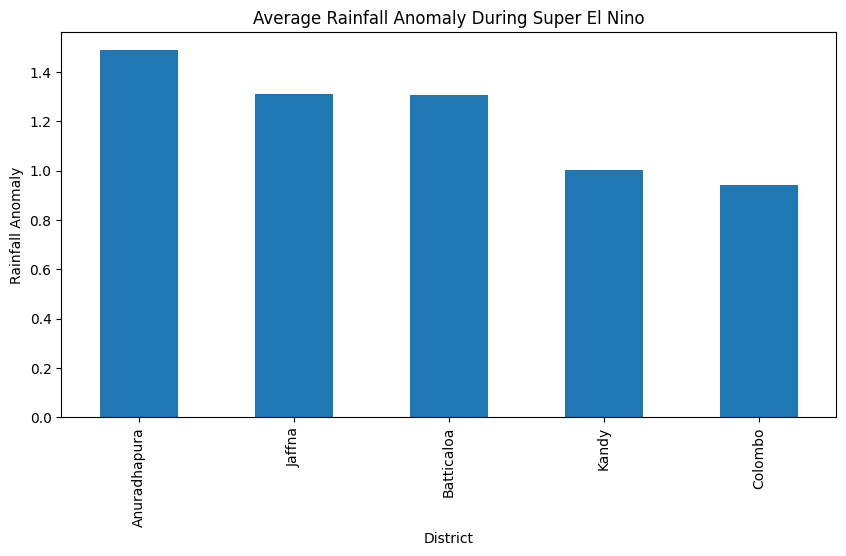

In [16]:
import matplotlib.pyplot as plt

impact_analysis.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Average Rainfall Anomaly During Super El Nino"
)

plt.ylabel(
    "Rainfall Anomaly"
)

plt.show()

In [17]:
from scipy.stats import ttest_ind

In [18]:
district = "Anuradhapura"

super_el_nino = sri_lanka_df[
    (sri_lanka_df["District"] == district) &
    (sri_lanka_df["ENSO_Category"] == "Super El Nino")
]["Rainfall"]

other_months = sri_lanka_df[
    (sri_lanka_df["District"] == district) &
    (sri_lanka_df["ENSO_Category"] != "Super El Nino")
]["Rainfall"]

t_stat, p_value = ttest_ind(
    super_el_nino,
    other_months,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.8248414444574892
P-value: 0.43268662040350075


In [19]:
district_correlations = (
    sri_lanka_df
    .groupby("District")
    .apply(
        lambda x: x["Rainfall"].corr(x["MEI"])
    )
    .sort_values(ascending=False)
)

print(district_correlations)

District
Anuradhapura   -0.015311
Colombo        -0.035779
Batticaloa     -0.045075
Jaffna         -0.045188
Kandy          -0.051943
dtype: float64


In [20]:
district_temp_impact = (
    sri_lanka_df[
        sri_lanka_df["ENSO_Category"] == "Super El Nino"
    ]
    .groupby("District")["Temperature"]
    .mean()
    .sort_values(ascending=False)
)

print(district_temp_impact)

District
Jaffna          27.993333
Batticaloa      27.906667
Colombo         26.346667
Anuradhapura    26.284444
Kandy           24.865556
Name: Temperature, dtype: float64


In [21]:
sri_lanka_df["Temperature_Anomaly"] = (
    sri_lanka_df["Temperature"]
    -
    sri_lanka_df.groupby("District")["Temperature"]
    .transform("mean")
)

sri_lanka_df.head()

,District,Date,Rainfall,Temperature,MEI,ENSO_Category,Rainfall_Anomaly,Temperature_Anomaly
0,Colombo,2000-01-01,0.94,25.40,-1.25,La Nina,-4.750769,-1.035513
1,Colombo,2000-02-01,2.94,26.56,-1.26,La Nina,-2.750769,0.124487
2,Colombo,2000-03-01,2.07,27.63,-1.37,La Nina,-3.620769,1.194487
3,Colombo,2000-04-01,3.65,27.49,-0.90,La Nina,-2.040769,1.054487
4,Colombo,2000-05-01,2.15,27.66,-0.94,La Nina,-3.540769,1.224487


In [22]:
sri_lanka_df["Rainfall_Score"] = (
    (
        sri_lanka_df["Rainfall_Anomaly"]
        -
        sri_lanka_df["Rainfall_Anomaly"].min()
    )
    /
    (
        sri_lanka_df["Rainfall_Anomaly"].max()
        -
        sri_lanka_df["Rainfall_Anomaly"].min()
    )
)

In [23]:
sri_lanka_df["Temperature_Score"] = (
    (
        sri_lanka_df["Temperature_Anomaly"]
        -
        sri_lanka_df["Temperature_Anomaly"].min()
    )
    /
    (
        sri_lanka_df["Temperature_Anomaly"].max()
        -
        sri_lanka_df["Temperature_Anomaly"].min()
    )
)

In [24]:
sri_lanka_df["SECII"] = (
    0.5 * sri_lanka_df["Rainfall_Score"]
    +
    0.5 * sri_lanka_df["Temperature_Score"]
)

sri_lanka_df.head()

,District,Date,Rainfall,Temperature,MEI,ENSO_Category,Rainfall_Anomaly,Temperature_Anomaly,Rainfall_Score,Temperature_Score,SECII
0,Colombo,2000-01-01,0.94,25.40,-1.25,La Nina,-4.750769,-1.035513,0.025798,0.321285,0.173542
1,Colombo,2000-02-01,2.94,26.56,-1.26,La Nina,-2.750769,0.124487,0.095522,0.482446,0.288984
2,Colombo,2000-03-01,2.07,27.63,-1.37,La Nina,-3.620769,1.194487,0.065192,0.631104,0.348148
3,Colombo,2000-04-01,3.65,27.49,-0.90,La Nina,-2.040769,1.054487,0.120274,0.611653,0.365964
4,Colombo,2000-05-01,2.15,27.66,-0.94,La Nina,-3.540769,1.224487,0.067981,0.635272,0.351626


In [25]:
secii_ranking = (
    sri_lanka_df[
        sri_lanka_df["ENSO_Category"]
        == "Super El Nino"
    ]
    .groupby("District")["SECII"]
    .mean()
    .sort_values(ascending=False)
)

print(secii_ranking)

District
Jaffna          0.342125
Batticaloa      0.340462
Colombo         0.338544
Kandy           0.328788
Anuradhapura    0.314385
Name: SECII, dtype: float64


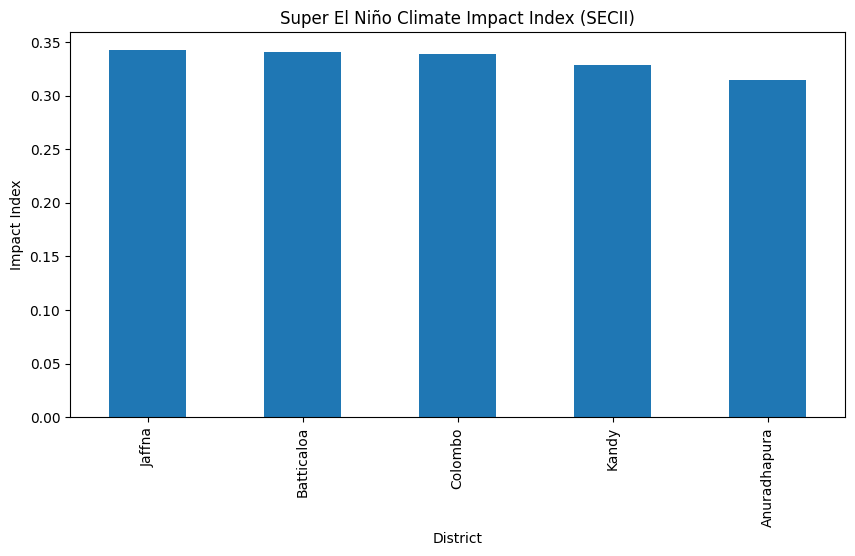

In [26]:
import matplotlib.pyplot as plt

secii_ranking.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Super El Niño Climate Impact Index (SECII)"
)

plt.ylabel("Impact Index")

plt.show()